(Surface-ADR)=
# Surface ADR

This time we consider an ADR equation posed on a surface
\begin{equation*}
\partial_t u +
 \nabla_\Gamma \cdot(\vec{b}_\Gamma u - d \nabla_\Gamma u) + cu = f
\end{equation*}
The coefficients represent the same quantitites defined in [the bulk ADR equation](Bulk-ADR), The difference is that the differential symbols $\nabla_\Gamma\cdot, \nabla_\Gamma$ are thus the tangential divergence and gradient instead of the classical Euclidean variant.


The steps to follow are the same as seen before, we just have to use the keyword `VorB = BND` in the constructor of the `ADRSolver` class to let the solver know that the species live on the surface.\

As a side comment, we also have to make sure that the advection field $\vec{b}_\Gamma$ is actually tangential to the surface in order to have correct computations.

Below we begin with an example of a surface with no boundary.

In [1]:
from ngsolve import *
from cosmos.utils.generate_surface_meshes import generate_circle
from cosmos.solvers.simulation import Simulation
from cosmos.solvers.adr import ADRSolver
from cosmos.solvers.tools import gradient
from ngsolve.webgui import Draw
import pandas as pd
import matplotlib.pyplot as plt


mesh, _ = generate_circle(maxh = 0.1)

dt = Parameter(0.1)
T = 1
t = Parameter(0)
simulation = Simulation(mesh=mesh, t=t, dt = dt, T = T, verbose = 2)

solver = ADRSolver(linear = True)
simulation.AddSolver(solver)

u_ex = cos(pi*x)*sin(pi*y)*cos(t)
d = 1+t
c = cos(x)
b = CF((-y,x))
normal = CF((x,y))/Norm(CF((x,y)))
P = Id(2) - OuterProduct(normal, normal)
flux1 = (b*u_ex).Compile()
flux2 = (- d*gradient(u_ex, P)).Compile()
flux = flux1 + flux2
rhs = (u_ex.Diff(t) + Trace(gradient(flux, P)) + c*u_ex).Compile()


solver.AddSpecie(VorB = BND,
            rhs = rhs,
            advection = b,
            diffusion = d,
            reaction = c,
            u0 = u_ex)

solver.ComputeError(ex_sol = u_ex, norm = 'L2', folderpath = './adr_results/', filename = 'surface_adr_errors')
solver.SaveSolution(folderpath = './adr_results/', filename = 'surface_adr_errors', n_steps = 100)
    
simulation.run()

print('Computed solution')
solver.draw_solution()
print('Exact solution')
Draw(u_ex, mesh)


------------------------------------------------------------
The mesh is a  2D mesh
The number of:
     vertices is:  388
     edges is:  1099
     faces is:  712
     facets is:  1099
     elements is:  712 ( = 0 if hypersurface)
Regions of co-dimension  0 :
 N.  1 region(s) called  default
Regions of co-dimension  1 :
 N.  2 region(s) called  boundary
Regions of co-dimension  2 :
 N.  2 region(s) called  default
------------------------------------------------------------ 

------------------------------------------------------------
This is a general solver for a Advection-Diffusion-Reaction problem.
               It allows to solve surface, bulk and coupled surface-bulk equations.
               It uses conforming H-1 elements of order 1.
Its parameters are
  - linear - with value  True
------------------------------------------------------------ 

Initializing...
Initialization successful 
                    N. 1  solvers have been initialized correctly
---------- 
Starting the 

	 Running Simulation...: 100%|████████████| 10/10 [00:00<00:00, 170.84it/s]

Simulation concluded successfully
----------
Computed solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Exact solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

We can see that the mesh used has volume elements, but the software automatically handles that and only works on the surface. Since we haven't specified the name of a domain, the solver assumes the equation is posed on the entire boundary. If one is interested in only part of it, then the flag `domain` can be used inside the `ADRSolver` class.


The plotting, saving and the error computation also take care of transporting the solution on a volume mesh if needed.

To note:
- trying to add a `VOL` equation to a mesh without volume elements will result in an error

In this case too we can plot the error between the computed and the exact solution

    Time   specie0
0    0.0  0.001164
1    0.1  0.010248
2    0.2  0.013711
3    0.3  0.014969
4    0.4  0.015295
5    0.5  0.015135
6    0.6  0.014658
7    0.7  0.013938
8    0.8  0.013016
9    0.9  0.011922
10   1.0  0.010685


<function matplotlib.pyplot.show(close=None, block=None)>

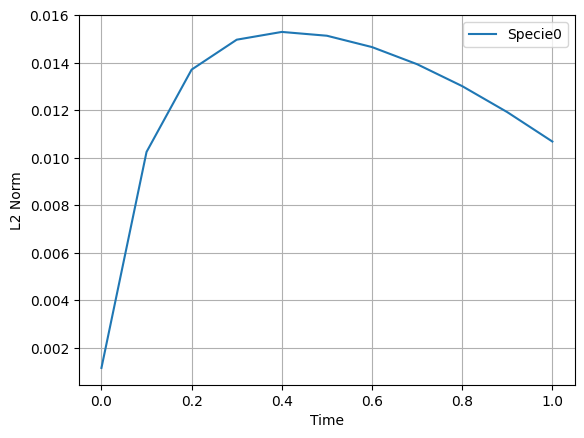

In [2]:
file_path = "./adr_results/surface_adr_errors"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

print(df)

import matplotlib.pyplot as plt
plt.plot(df['Time'], df['specie0'], label = 'Specie0')
plt.xlabel('Time')
plt.ylabel('L2 Norm')
plt.grid()
plt.legend()
plt.show

Let's try now a case with an open boundary, such as an half sphere. In this case, both Dirichlet and Neumann boundary conditions can be applied, as seen for the bulk case.

We added a variable so that one can switch between the two versions easily

------------------------------------------------------------
The mesh is a  3D mesh
! The mesh is also an hypersurface embedded in  3D !
The number of:
     vertices is:  780
     edges is:  2274
     faces is:  1495
     facets is:  1495
     elements is:  0 ( = 0 if hypersurface)
Regions of co-dimension  0 :
 N.  1 region(s) called  
Regions of co-dimension  1 :
 N.  1 region(s) called  default
Regions of co-dimension  2 :
 N.  1 region(s) called  bottom
------------------------------------------------------------ 

------------------------------------------------------------
This is a general solver for a Advection-Diffusion-Reaction problem.
               It allows to solve surface, bulk and coupled surface-bulk equations.
               It uses conforming H-1 elements of order 1.
Its parameters are
  - linear - with value  True
------------------------------------------------------------ 

Initializing...
Initialization successful 
                    N. 1  solvers have been init

	 Running Simulation...: 100%|█████████████| 10/10 [00:00<00:00, 29.35it/s]

Simulation concluded successfully
----------

Computed solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…


Exact solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

    Time   specie0
0    0.0  0.007952
1    0.1  0.010843
2    0.2  0.012142
3    0.3  0.012417
4    0.4  0.012255
5    0.5  0.011844
6    0.6  0.011258
7    0.7  0.010531
8    0.8  0.009684
9    0.9  0.008734
10   1.0  0.007693


<function matplotlib.pyplot.show(close=None, block=None)>

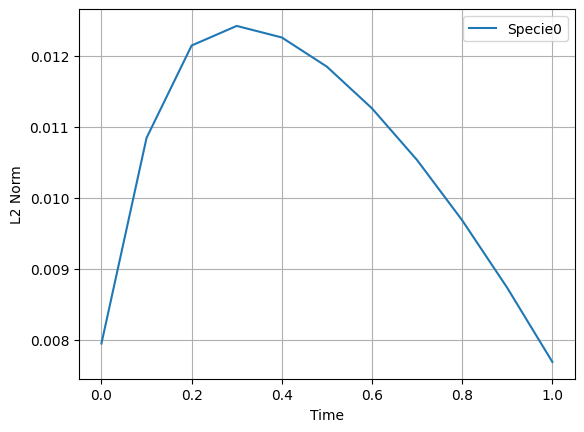

In [3]:
from cosmos.utils.generate_surface_meshes import generate_half_sphere

bc = 'dir'

mesh, _ = generate_half_sphere(maxh = 0.1)

dt = Parameter(0.1)
T = 1
t = Parameter(0)
simulation = Simulation(mesh=mesh, t=t, dt = dt, T = T, verbose = 2)

solver = ADRSolver(linear = True)
simulation.AddSolver(solver)

u_ex = cos(pi*x)*sin(pi*y)*cos(t)
normal = CF((x,y,z))/Norm(CF((x,y,z)))
P = Id(3) - OuterProduct(normal, normal)
d = 1 + x**2
c = cos(x)
b = P*CF((-z,0,x))
flux1 = (b*u_ex).Compile()
flux2 = (- d*gradient(u_ex, P)).Compile()
flux = flux1 + flux2
rhs = (u_ex.Diff(t) + Trace(gradient(flux, P)) + c*u_ex).Compile()
neu_b = {'bottom': flux1}
neu_d = {'bottom': flux2}
dir_d = {'bottom': u_ex}
dir_b = {'bottom': u_ex}

if bc == 'dir':
    solver.AddSpecie(VorB = BND,
                rhs = rhs,
                advection = b,
                diffusion = d,
                reaction = c,
                u0 = u_ex,
                dir_d = dir_d,
                dir_b = dir_b)
elif bc == 'neu':
    solver.AddSpecie(VorB = BND,
                rhs = rhs,
                advection = b,
                diffusion = d,
                reaction = c,
                u0 = u_ex,
                neu_d = neu_d,
                neu_b = neu_b)
    
solver.ComputeError(ex_sol = u_ex, norm = 'L2', folderpath = './adr_results/', filename = 'surface1_adr_errors')
solver.SaveSolution(folderpath = './adr_results/', filename = 'surface1_adr_errors', n_steps = 100)
    
simulation.run()

print('\nComputed solution')
solver.draw_solution()
print('\nExact solution')
Draw(u_ex, mesh)

file_path = "./adr_results/surface1_adr_errors"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

print(df)

import matplotlib.pyplot as plt
plt.plot(df['Time'], df['specie0'], label = 'Specie0')
plt.xlabel('Time')
plt.ylabel('L2 Norm')
plt.grid()
plt.legend()
plt.show



Another borderline case could be the one of a 1D line immersed in 2D space. We show in the following how the solver correctly handles this case.

	 Running Simulation...: 100%|████████████| 10/10 [00:00<00:00, 125.06it/s]


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

    Time   specie0
0    0.0  0.003221
1    0.1  0.018751
2    0.2  0.021751
3    0.3  0.022225
4    0.4  0.021930
5    0.5  0.021253
6    0.6  0.020305
7    0.7  0.019127
8    0.8  0.017742
9    0.9  0.016170
10   1.0  0.014433


<function matplotlib.pyplot.show(close=None, block=None)>

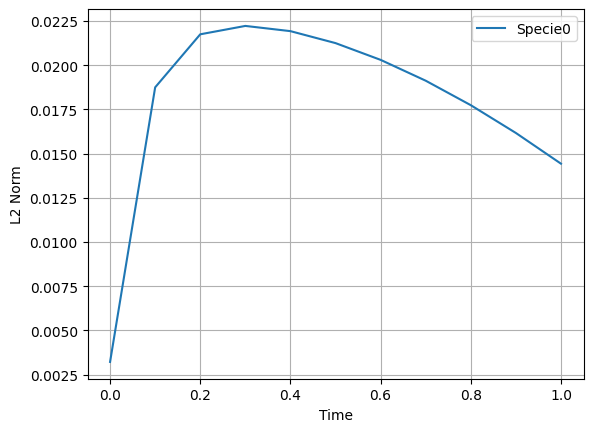

In [4]:
from cosmos.utils.generate_surface_meshes import generate_arc

bc = 'dir'

mesh, _ = generate_arc(r=1, N=20)

dt = Parameter(0.1)
T = 1
t = Parameter(0)
simulation = Simulation(mesh=mesh, t=t, dt = dt, T = T)

solver = ADRSolver(linear = True)
simulation.AddSolver(solver)

u_ex = cos(pi*x)*sin(pi*y)*cos(t)
normal = CF((x,y))/Norm(CF((x,y)))
P = Id(2) - OuterProduct(normal, normal)
d = 1 + x**2
c = cos(x)
b = P*CF((2, 1))
flux1 = (b*u_ex).Compile()
flux2 = (- d*gradient(u_ex, P)).Compile()
flux = flux1 + flux2
rhs = (u_ex.Diff(t) + Trace(gradient(flux, P)) + c*u_ex).Compile()
neu_b = {'boundary': flux1}
neu_d = {'boundary': flux2}
dir_d = {'boundary': u_ex}
dir_b = {'boundary': u_ex}

if bc == 'dir':
    solver.AddSpecie(VorB = BND,
                rhs = rhs,
                advection = b,
                diffusion = d,
                reaction = c,
                u0 = u_ex,
                dir_d = dir_d,
                dir_b = dir_b)
elif bc == 'neu':
    solver.AddSpecie(VorB = BND,
                rhs = rhs,
                advection = b,
                diffusion = d,
                reaction = c,
                u0 = u_ex,
                neu_d = neu_d,
                neu_b = neu_b)
    
solver.ComputeError(ex_sol = u_ex, norm = 'L2', folderpath = './adr_results/', filename = 'surface2_adr_errors')
    
simulation.run()

solver.draw_solution()

file_path = "./adr_results/surface2_adr_errors"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

print(df)

import matplotlib.pyplot as plt
plt.plot(df['Time'], df['specie0'], label = 'Specie0')
plt.xlabel('Time')
plt.ylabel('L2 Norm')
plt.grid()
plt.legend()
plt.show